# 1. Import Required Libraries


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, auc, classification_report, confusion_matrix, f1_score, precision_score, precision_recall_curve, recall_score, roc_auc_score



# 2. Load and Explore Data


In [12]:
df = pd.read_csv('StudentPerformanceFactors.csv')
print(f"Loaded dataset: StudentPerformanceFactors.csv")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("Missing values per column:\n", df.isnull().sum())
df = df.dropna()
print(f"After dropping missing values: {df.shape}")



Loaded dataset: StudentPerformanceFactors.csv
Shape: (6607, 20)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
Missing values per column:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Dis

# 3. Prepare Features and Target


In [13]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
X = pd.get_dummies(X, drop_first=True)
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")



Number of features: 27
Number of samples: 6378


# 4. Train-Test Split (No scaling needed for Random Forest)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")



Training set shape: (5102, 27)
Test set shape: (1276, 27)


# 5. Model Training



In [15]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")



Random Forest Regressor model trained.


# 6. Model Evaluation (Regression Metrics)


In [16]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest Regressor Results:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")



Random Forest Regressor Results:
Mean Absolute Error: 1.2463
Mean Squared Error: 6.0461
R-squared Score: 0.6109


# 7. Actual vs Predicted Plot


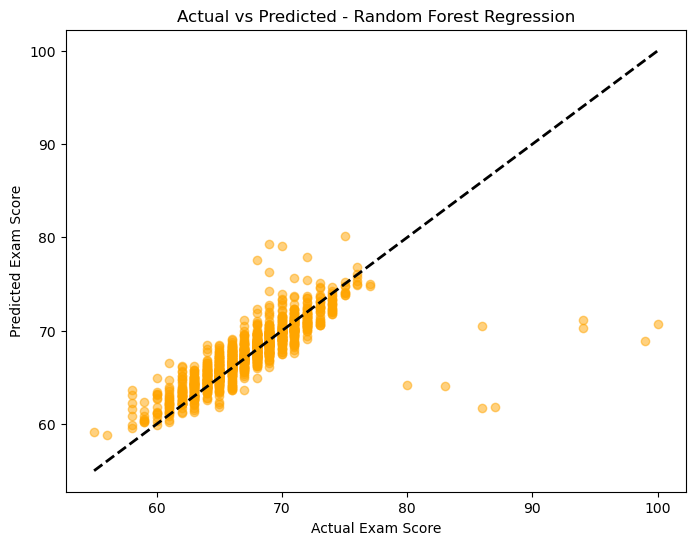

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted - Random Forest Regression')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()


# 8. Classification Metrics on Continuous Data (Threshold = 60)


In [18]:
PASS_THRESHOLD = 60
y_test_class = (y_test >= PASS_THRESHOLD).astype(int)
y_pred_class = (y_pred >= PASS_THRESHOLD).astype(int)
print(f"\n--- CLASSIFICATION METRICS (Threshold >= {PASS_THRESHOLD}) ---")
print("Confusion Matrix:\n", confusion_matrix(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
roc_auc = roc_auc_score(y_test_class, y_pred)
print(f"Precision Score : {precision:.4f}")
print(f"Recall Score    : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC AUC Score   : {roc_auc:.4f}\n")




--- CLASSIFICATION METRICS (Threshold >= 60) ---
Confusion Matrix:
 [[   4   13]
 [   1 1258]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.24      0.36        17
           1       0.99      1.00      0.99      1259

    accuracy                           0.99      1276
   macro avg       0.89      0.62      0.68      1276
weighted avg       0.99      0.99      0.99      1276

Precision Score : 0.9898
Recall Score    : 0.9992
F1 Score        : 0.9945
ROC AUC Score   : 0.9824



# 9. Precision-Recall Curve and PR AUC


PR AUC Score    : 0.9998



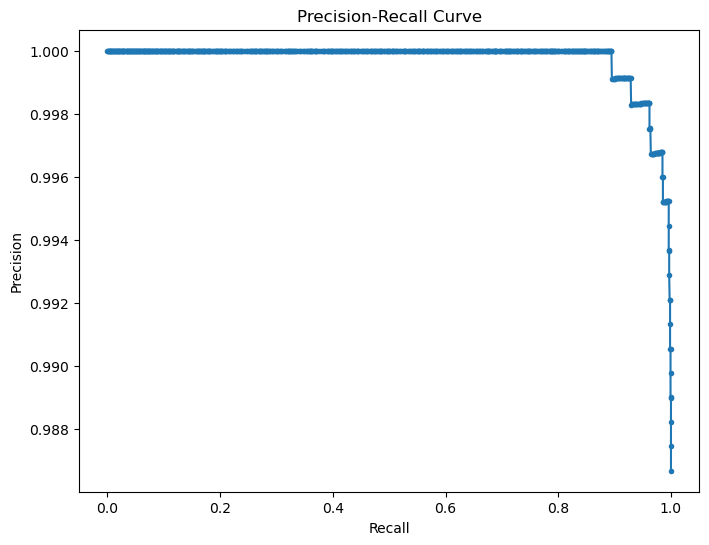

In [19]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test_class, y_pred)
pr_auc = auc(recall_curve, precision_curve)
print(f"PR AUC Score    : {pr_auc:.4f}\n")
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, marker='.')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()



# 10. Sample Data Prediction


In [20]:
print("\n--- SAMPLE PREDICTION ---")
sample_features = X_test.iloc[[0]]
actual_score = y_test.iloc[0]
predicted_score = model.predict(sample_features)[0]
print(f"Actual Exam Score    : {actual_score}")
print(f"Predicted Exam Score : {predicted_score:.2f}")


--- SAMPLE PREDICTION ---
Actual Exam Score    : 74
Predicted Exam Score : 73.45
